## AdaBoost :: Step-by-Step Walkthrough

**AdaBoost** (short for *Adaptive Boosting*) is an ensemble learning method. Instead of training one big model, it trains many small, simple models one after another. Each new model pays extra attention to the examples the previous model got wrong.

Think of it like a study group preparing for an exam. The first student tries all the questions. The second student focuses extra time on the ones the first got wrong. The third focuses on what both earlier ones missed. At the end, you combine all their answers, but you give more weight to the students who were generally better.

---

## Key Ideas

| Concept | Plain English |
|---|---|
| **Weak Classifier** | A simple model that is just slightly better than random guessing. Here we use a Decision Tree with depth 1, called a "stump". |
| **Sample Weight** | How much attention the next model should pay to each data point. |
| **Model Weight (alpha)** | How much to trust a model when making the final prediction. |
| **Final Prediction** | A weighted vote from all the stumps. |


In [50]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree
from mlxtend.plotting import plot_decision_regions

### Create the Dataset

Create a small, hand-crafted dataset with:
- **col_1** and **col_2**: two input features (like coordinates on a map)
- **target**: the label we want to predict (0 or 1)

This tiny 10-row dataset makes it easy to trace every AdaBoost step by hand.

In [51]:
data = {
    'col_1' :[1,2,3,4,5,6,6,7,9,9],
    'col_2' : [5,3,6,8,1,9,5,8,9,2],
    'target' : [1,1,0,1,0,1,0,1,0,0]
}
data = pd.DataFrame(data)
data

,col_1,col_2,target
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


###  Visualize the Dataset

Plot each point on a 2D chart colored by its label (0 or 1). 

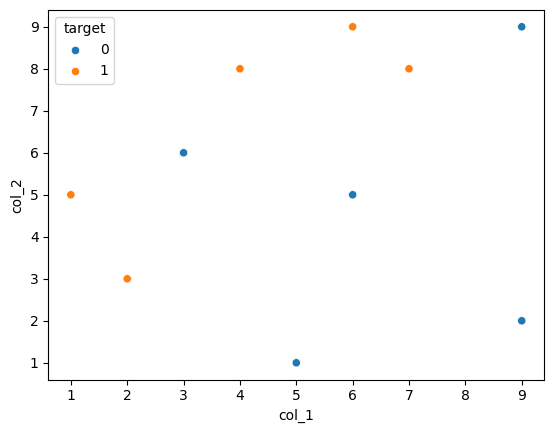

In [52]:
sns.scatterplot(x=data['col_1'],y=data['col_2'],hue=data['target']);

### Initialize Sample Weights

At the start of AdaBoost, **every data point gets the same weight**.

If there are N points, each weight starts at 1/N.

Here N = 10, so each point starts with weight = **0.1**.

> **Why weights?**
> Weights control how much attention the next stump pays to each example.
> A higher weight means: "pay more attention to this point, because previous models got it wrong."

In [53]:
data['Weight'] = 1/data.shape[0]
data

,col_1,col_2,target,Weight
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


### Train the First Weak Classifier (Decision Stump)

A **Decision Stump** is just a Decision Tree with a maximum depth of 1. It makes exactly one split.

This is intentionally simple. AdaBoost does not need great individual models; it turns many weak models into one strong one.

In [54]:
X = data.iloc[:,0:2].values
y = data.iloc[:,2].values
decision_tree  = DecisionTreeClassifier(max_depth=1)
decision_tree.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Visualize the First Stump and Its Decision Boundary

The left panel shows the stump's one split rule. The right panel shows how that rule divides the feature space into two regions (predicted 0 and predicted 1).

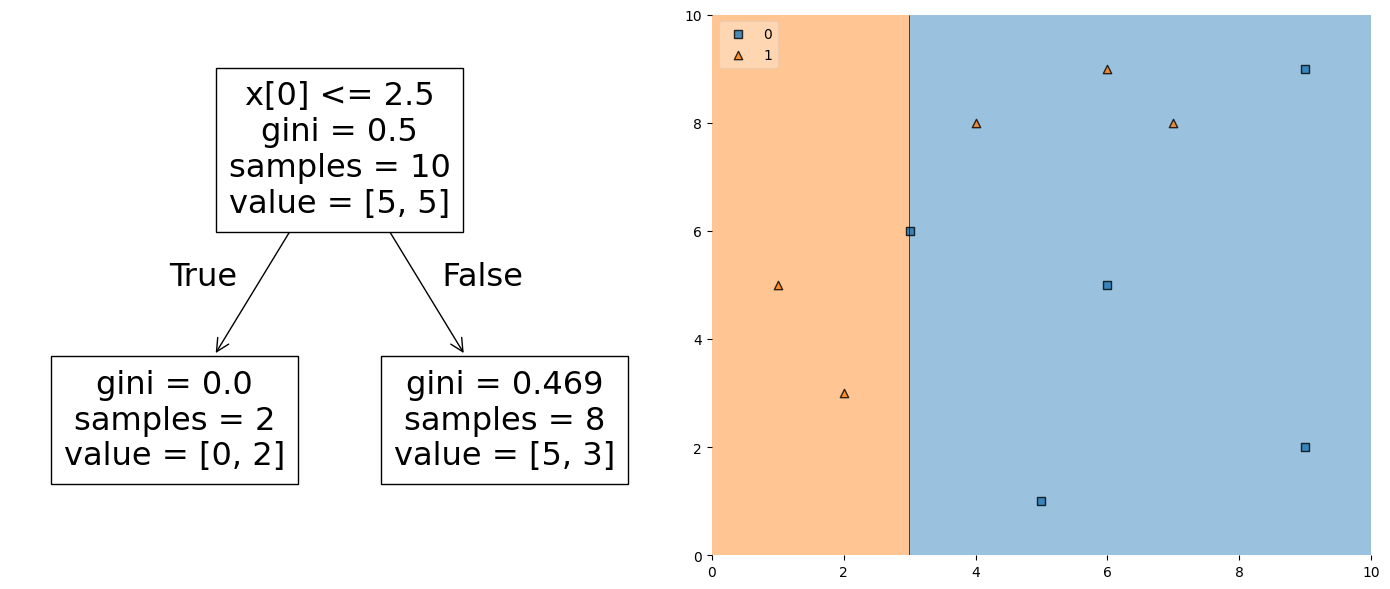

In [55]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plot_tree(decision_tree)
plt.subplot(1,2,2)
plot_decision_regions(X,y,clf = decision_tree,legend=2)
plt.tight_layout()
plt.show()         

### Get Predictions from the First Stump

Ask the first stump to classify every training example. Comparing `target` vs `y_pred` shows which points it got wrong — those are the ones AdaBoost will focus on next.

In [56]:
data['y_pred'] = decision_tree.predict(X)
data.head(4)

,col_1,col_2,target,Weight,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0


### Calculate the Model Weight (Alpha)

**Alpha** tells us how much to trust this stump in the final vote.

The formula is:

$$\alpha = 0.5 \times \ln\!\left(\frac{1 - \text{error}}{\text{error}}\right)$$

- If error = 0 (perfect model) → alpha is very large (trust it a lot)
- If error = 0.5 (random guessing) → alpha = 0 (do not trust it)
- If error > 0.5 (worse than random) → alpha is negative (flip its vote)


In [57]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error))

alpha1 = calculate_model_weight(0.3)
alpha1    

np.float64(0.42364893019360184)

### Update Sample Weights

After measuring the first stump's performance, **adjust the weights**:

- Points the model **got wrong** → weight goes **up** (multiply by $e^{+\alpha}$)
- Points the model **got right** → weight goes **down** (multiply by $e^{-\alpha}$)

This ensures the next stump will focus on the hard examples the first stump failed on.

In [58]:
def update_row_weights(row, alpha=0.423):
    """
    Update a single row's weight based on whether the stump was correct.

    - Correct prediction  -> reduce weight  (no need to focus here)
    - Wrong prediction    -> increase weight (focus here next round)
    
    """
    if row['target'] == row['y_pred']:   # correct prediction
        return row['Weight'] * np.exp(-alpha)
    else:                                 # wrong prediction
        return row['Weight'] * np.exp(alpha)

# Apply the weight update rule to every row in the dataset
data['updated_weights'] = data.apply(update_row_weights, axis=1)
data.head(4)

,col_1,col_2,target,Weight,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653


### Normalize the Updated Weights

After updating, the weights may no longer sum to 1. We **normalize** them so they still behave like probabilities.

Normalization: divide each weight by the total sum of all weights.

In [59]:
data['updated_weights'].sum()

np.float64(0.9165153319682015)

In [60]:
data['normalized_weights'] = data['updated_weights']/data['updated_weights'].sum()
print("Sum of Normalized Weights :: ",data['normalized_weights'].sum())
data.head(4)

Sum of Normalized Weights ::  1.0


,col_1,col_2,target,Weight,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559


### Build a Probability Ladder for Sampling

To build the next training set, sample with replacement using the normalized weights as probabilities. Points with higher weights are more likely to be picked.

Use a **cumulative sum** approach:
- Each row occupies a range on the number line [0, 1] proportional to its weight
- When we draw a random number, it falls into exactly one row's range
- That row gets picked

In [61]:
data['cumsum_upper'] = np.cumsum(data['normalized_weights'])
data['cumsum_lower'] = data['cumsum_upper'] - data['normalized_weights']
data[['col_1','col_2','target','Weight','y_pred','updated_weights','cumsum_lower','cumsum_upper']].head(3)

,col_1,col_2,target,Weight,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425


### Sample a New Training Dataset

For each of the N samples we need:
1. Draw a random number between 0 and 1
2. Find which row's range that number falls into
3. Pick that row



In [62]:
def create_new_dataset(data):
    """
    Build a new dataset of the same size by sampling rows with replacement.
    Rows with higher normalized weights are more likely to be selected.
    """
    indices = []
    for i in range(data.shape[0]):
        a = np.random.random()  # draw a uniform random number in [0, 1]
        # Find which row this random number lands in
        for index, row in data.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

# Get the row indices for the second training set
index_values = create_new_dataset(data)
index_values

[3, 2, 5, 1, 8, 7, 8, 7, 7, 8]

In [63]:
second_data = data.iloc[index_values,[0,1,2,3]]
second_data.head(3)

,col_1,col_2,target,Weight
3,4,8,1,0.1
2,3,6,0,0.1
5,6,9,1,0.1


### Train the Second Decision Stump

Train a brand new stump on `second_data`. Because this dataset over-samples the points the first stump got wrong, the second stump will naturally focus on those hard cases.

In [64]:
X = second_data.iloc[:,0:2].values
y = second_data.iloc[:,2].values
decision_tree1 = DecisionTreeClassifier(max_depth=1)
decision_tree1.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


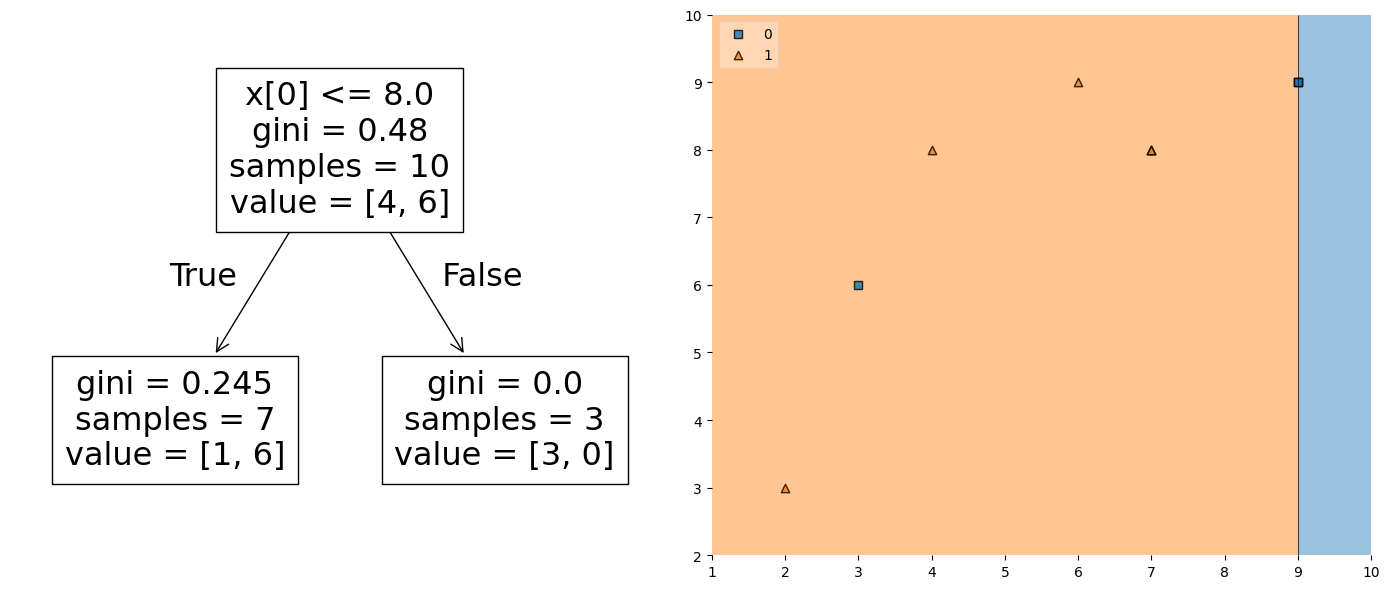

In [65]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plot_tree(decision_tree1);
plt.subplot(1,2,2)
plot_decision_regions(X,y,clf = decision_tree1,legend=2);  
plt.tight_layout()
plt.show()         

In [66]:
second_data['y_pred'] = decision_tree1.predict(X)
second_data

,col_1,col_2,target,Weight,y_pred
3,4,8,1,0.1,1
2,3,6,0,0.1,1
5,6,9,1,0.1,1
1,2,3,1,0.1,1
8,9,9,0,0.1,0
7,7,8,1,0.1,1
8,9,9,0,0.1,0
7,7,8,1,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,0


### Calculate Alpha for the Second Stump

The second stump has an error ~ **0.1** — it only got 1 out of 10 points wrong. A lower error means a higher alpha (more trust in this model).

In [67]:
alpha2 = calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886681098)

### Update and Normalize Weights for Round 3

Using the second stump's alpha, update the weights once more so the third stump focuses on what the first two still get wrong.

In [68]:
def update_row_weights(row, alpha=1.09):
    """
    Same logic as before, but using alpha2 = 1.09 for the second stump.
    Correct prediction  -> decrease weight
    Wrong prediction    -> increase weight
    """
    if row['target'] == row['y_pred']:
        return row['Weight'] * np.exp(-alpha)
    else:
        return row['Weight'] * np.exp(alpha)

In [69]:
second_data['updated_weights'] = second_data.apply(update_row_weights,axis=1)
second_data

,col_1,col_2,target,Weight,y_pred,updated_weights
3,4,8,1,0.1,1,0.033622
2,3,6,0,0.1,1,0.297427
5,6,9,1,0.1,1,0.033622
1,2,3,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622


In [70]:
second_data['normalized_weights'] = second_data['updated_weights']/second_data['updated_weights'].sum()
second_data

,col_1,col_2,target,Weight,y_pred,updated_weights,normalized_weights
3,4,8,1,0.1,1,0.033622,0.056034
2,3,6,0,0.1,1,0.297427,0.495694
5,6,9,1,0.1,1,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034


In [71]:
second_data['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [72]:
second_data['cumsum_upper'] = np.cumsum(second_data['normalized_weights'])
second_data['cumsum_lower'] = second_data['cumsum_upper'] - second_data['normalized_weights']
second_data[['col_1','col_2','target','Weight','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,col_1,col_2,target,Weight,y_pred,updated_weights,cumsum_lower,cumsum_upper
3,4,8,1,0.1,1,0.033622,0.000000,0.056034
2,3,6,0,0.1,1,0.297427,0.056034,0.551728
5,6,9,1,0.1,1,0.033622,0.551728,0.607762
1,2,3,1,0.1,1,0.033622,0.607762,0.663796
8,9,9,0,0.1,0,0.033622,0.663796,0.719830
7,7,8,1,0.1,1,0.033622,0.719830,0.775864
8,9,9,0,0.1,0,0.033622,0.775864,0.831898
7,7,8,1,0.1,1,0.033622,0.831898,0.887932
7,7,8,1,0.1,1,0.033622,0.887932,0.943966
8,9,9,0,0.1,0,0.033622,0.943966,1.000000


In [73]:
index_values = create_new_dataset(second_data)
third_data = second_data.iloc[index_values,[0,1,2,3]]
third_data

,col_1,col_2,target,Weight
5,6,9,1,0.1
2,3,6,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1
1,2,3,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1


In [74]:
X = third_data.iloc[:,0:2].values
y = third_data.iloc[:,2].values
decision_tree2 = DecisionTreeClassifier(max_depth=1)
decision_tree2.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


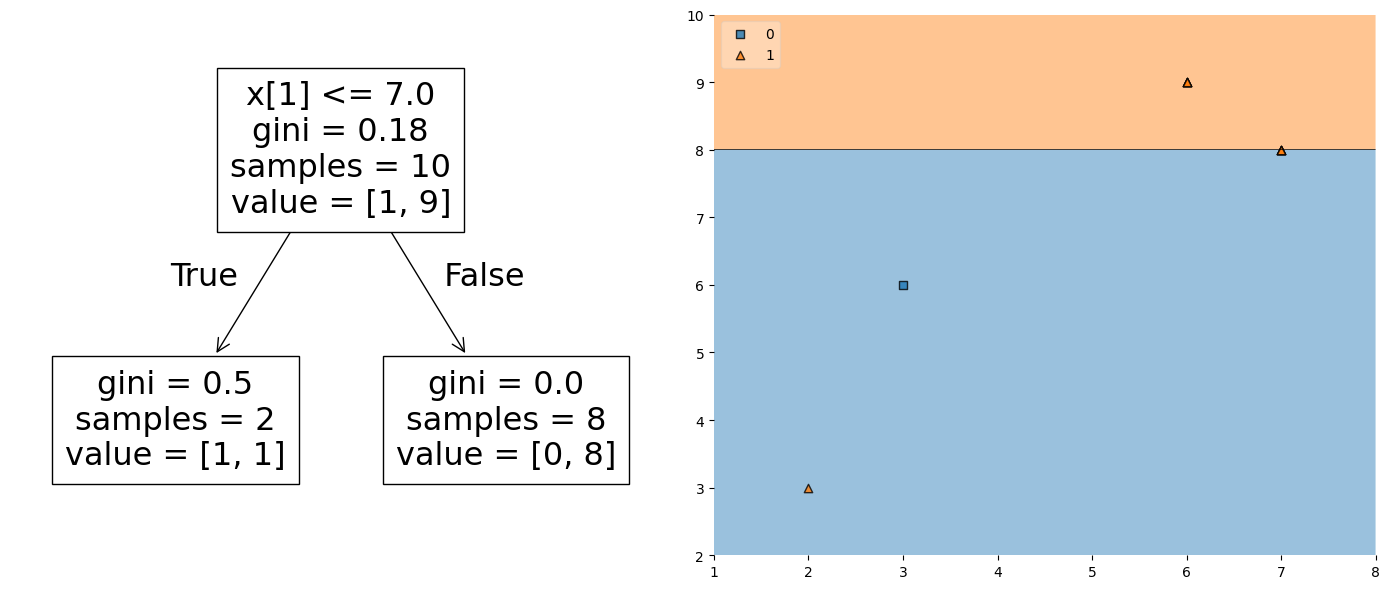

In [75]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plot_tree(decision_tree2)
plt.subplot(1,2,2)
plot_decision_regions(X,y,clf = decision_tree2,legend=2) 
plt.tight_layout()
plt.show()        

In [76]:
third_data['y_pred'] = decision_tree1.predict(X)
third_data

,col_1,col_2,target,Weight,y_pred
5,6,9,1,0.1,1
2,3,6,0,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
7,7,8,1,0.1,1
5,6,9,1,0.1,1
7,7,8,1,0.1,1
1,2,3,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1


In [77]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [78]:
print("Alpha - 1 ::",alpha1)
print("Alpha - 2 ::",alpha2)
print("Alpha - 3 ::",alpha3)

Alpha - 1 :: 0.42364893019360184
Alpha - 2 :: 1.0986122886681098
Alpha - 3 :: -0.4236489301936017


### Summary of Alpha Values

| Stump | Error | Alpha | Interpretation |
|---|---|---|---|
| Stump 1 | 0.3 | ~+0.42 | Decent model, moderate trust |
| Stump 2 | 0.1 | ~+1.10 | Strong model, high trust |
| Stump 3 | 0.7 | ~-0.42 | Worse than random; its vote is flipped |

A **negative alpha** means AdaBoost will invert that stump's prediction. A consistently wrong model is still useful, you just flip it.

### Make a Final Prediction (Weighted Vote)

To classify a new point, each stump casts a vote and we weight it by that stump's alpha:

$$\hat{y} = \text{sign}\!\left(\alpha_1 \cdot h_1(x) + \alpha_2 \cdot h_2(x) + \alpha_3 \cdot h_3(x)\right)$$

- A positive total sum → final prediction is class 1
- A negative total sum → final prediction is class 0

Test on two example points: `[1, 5]` (true label = 1) and `[9, 9]` (true label = 0).

In [79]:
query = np.array([1,5]).reshape(1,2)
print("Prediction by Decision Tree - 1 ::",decision_tree.predict(query))
print("Prediction by Decision Tree - 2 ::",decision_tree1.predict(query))
print("Prediction by Decision Tree - 3 ::",decision_tree2.predict(query))

Prediction by Decision Tree - 1 :: [1]
Prediction by Decision Tree - 2 :: [1]
Prediction by Decision Tree - 3 :: [0]


In [80]:
print("alpha1*1 + alpha2*(1) + alpha3*(1) ::",alpha1*1 + alpha2*(1) + alpha3*(1))
print("np.sign(1.09) ::",np.sign(1.09))

alpha1*1 + alpha2*(1) + alpha3*(1) :: 1.09861228866811
np.sign(1.09) :: 1.0


In [81]:
query = np.array([9,9]).reshape(1,2)
print("Prediction by Decision Tree - 1 ::",decision_tree.predict(query))
print("Prediction by Decision Tree - 2 ::",decision_tree1.predict(query))
print("Prediction by Decision Tree - 3 ::",decision_tree2.predict(query))

Prediction by Decision Tree - 1 :: [0]
Prediction by Decision Tree - 2 :: [0]
Prediction by Decision Tree - 3 :: [1]
